**Set environment**

In [1]:
suppressMessages(suppressWarnings(source("../run_config_project.R")))
show_env()

BASE DIRECTORY (FD_BASE): /hpc/group/igvf/kk319 
REPO DIRECTORY (FD_REPO): /hpc/group/igvf/kk319/repo 
WORK DIRECTORY (FD_WORK): /hpc/group/igvf/kk319/work 
DATA DIRECTORY (FD_DATA): /hpc/group/igvf/kk319/data 

You are working with      IGVF BlueSTARR 
PATH OF PROJECT (FD_PRJ): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR 
PROJECT RESULTS (FD_RES): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results 
PROJECT SCRIPTS (FD_EXE): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/scripts 
PROJECT DATA    (FD_DAT): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/data 
PROJECT NOTE    (FD_NBK): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/notebooks 
PROJECT DOCS    (FD_DOC): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/docs 
PROJECT LOG     (FD_LOG): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/log 
PROJECT REF     (FD_REF): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/references 



## Import data

**Check file existence**

In [2]:
### set file directory
txt_fdiry = file.path(FD_DAT, "variant_bluestarr_richard", "closed")
vec = dir(txt_fdiry)
for (txt in vec){cat(txt, "\n")}

annotated_snv_sites_filtered.tsv.gz 
annotated_snv_sites.tsv.gz 
regions_GoF_only.fasta.gz 
regions.fasta.gz 


**Import table**

In [3]:
### set file directory
txt_fdiry = file.path(FD_DAT, "variant_bluestarr_richard", "closed")
txt_fname = "annotated_snv_sites_filtered.tsv.gz"
txt_fpath = file.path(txt_fdiry, txt_fname)

### read table
dat = read_tsv(txt_fpath, show_col_types = FALSE)

### assign and show
dat_region_variant_import = dat
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 1884977       6


region,pos0,delta,ref,obs,unobs
chr4:74487576-74488141,74487586,0.9649841,A,G,C
chr9:135685425-135685942,135685432,0.9454227,G,G,C
chr1:173251481-173251541,173251490,0.9101272,G,G,C


In [5]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard")
txt_fname = "variant_closed_gof_bluestarr.tsv.gz"
txt_fpath = file.path(txt_fdiry, txt_fname)

### read table
dat = read_tsv(txt_fpath, show_col_types = FALSE)

### assign and show
dat_region_variant_annot = dat
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 1884977      10


Chrom,ChromStart,ChromEnd,Region,Variant_ID,Pos0,Ref,Obs,Unobs,Delta
chr4,74487576,74488141,chr4:74487576-74488141,chr4:74487586:A:G:C,74487586,A,G,C,0.9649841
chr9,135685425,135685942,chr9:135685425-135685942,chr9:135685432:G:G:C,135685432,G,G,C,0.9454227
chr1,173251481,173251541,chr1:173251481-173251541,chr1:173251490:G:G:C,173251490,G,G,C,0.9101272


In [6]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "batches_dev")
txt_fname = "motifscan_variant_closed_gof_bluestarr_flank35_dev1000_delta_summary.tsv"
txt_fpath = file.path(txt_fdiry, txt_fname)

### read table
dat = read_tsv(txt_fpath, show_col_types = FALSE)

### assign and show
dat_region_variant_score = dat
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 879000     11


seq_id,motif_id,fwd_max,fwd_mean,fwd_median,rev_max,rev_mean,rev_median,merge_max,merge_mean,merge_median
chr9:135685432:G:G:C,MA0002.3 Runx1,2.846921,-0.5678376,0,19.922160,0.5678376,0,19.922160,0.6305606,0
chr9:135685432:G:G:C,MA0003.5 TFAP2A,6.356318,0.0517594,0,6.152052,-0.0517594,0,6.356318,0.0627520,0
chr9:135685432:G:G:C,MA0004.1 Arnt,19.931569,-0.2413874,0,19.931569,0.2413874,0,19.931569,0.2413874,0


In [7]:
dat_top1000 <- dat_region_variant_annot %>%
    dplyr::arrange(desc(Delta)) %>%
    dplyr::slice_head(n = 1000)

head(dat_top1000)

Chrom,ChromStart,ChromEnd,Region,Variant_ID,Pos0,Ref,Obs,Unobs,Delta
<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>
chr4,74487576,74488141,chr4:74487576-74488141,chr4:74487586:A:G:C,74487586,A,G,C,0.9649841
chr9,135685425,135685942,chr9:135685425-135685942,chr9:135685432:G:G:C,135685432,G,G,C,0.9454227
chr1,173251481,173251541,chr1:173251481-173251541,chr1:173251490:G:G:C,173251490,G,G,C,0.9101272
chr1,147523084,147523503,chr1:147523084-147523503,chr1:147523391:G:G:C,147523391,G,G,C,0.9088001
chr18,54580694,54581420,chr18:54580694-54581420,chr18:54580749:A:G:T,54580749,A,G,T,0.8622959
chr7,80949320,80949853,chr7:80949320-80949853,chr7:80949454:A:G:C,80949454,A,G,C,0.8393378


In [10]:
vec_txt_seq_idx = unique(dat_region_variant_score$seq_id)
length(vec_txt_seq_idx)        # should be 1000
length(unique(dat_top1000$Variant_ID))  # also 1000

sum(dat_top1000$Variant_ID %in% vec_txt_seq_idx)

[1] 1000

[1] 1000

[1] 1000

In [12]:
library(pheatmap)

In [19]:
dat = dat_region_variant_score
dat = dat %>% dplyr::select(seq_id, motif_id, merge_max)

dat = dat %>%
    tidyr::pivot_wider(
        names_from  = motif_id,
        values_from = merge_max
    )
dat = dat %>% column_to_rownames(var = "seq_id")
mat = as.matrix(dat)

mat_region_variant_score = mat
print(dim(dat))
print(max(mat_region_variant_score))
head(dat)

[1] 1000  879
[1] 19.93157


,MA0002.3 Runx1,MA0003.5 TFAP2A,MA0004.1 Arnt,MA0006.2 Ahr::Arnt,MA0007.4 Ar,MA0009.2 TBXT,MA0014.4 PAX5,MA0017.3 NR2F1,MA0018.5 CREB1,MA0019.2 Ddit3::Cebpa,⋯,MA2332.1 ZNF175,MA2333.1 ZNF35,MA2334.1 ZNF547,MA2335.1 ZNF558,MA2336.1 ZSCAN21,MA2337.1 Nr1h3,MA2338.1 Ppara,MA2339.1 Nanog,MA2340.1 Zbtb2,MA2341.1 FEZF2
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr9:135685432:G:G:C,19.92216,6.356318,19.93157,19.93157,19.92631,19.93102,5.229969,19.93157,5.295070,19.89409,⋯,6.838168,3.798494,7.159868,12.89822,5.092554,11.910646,8.000249,6.294136,5.451946,19.89295
chr4:74487586:A:G:C,19.92216,6.356318,19.93157,19.93157,19.92631,19.93102,5.229969,19.93157,5.295070,19.89409,⋯,6.838168,3.798494,7.159868,12.89822,5.092554,11.910646,8.000249,6.294136,5.451946,19.89295
chr1:173251490:G:G:C,19.92216,6.356318,19.93157,19.93157,19.92631,19.93102,5.229969,19.93157,5.295070,19.89409,⋯,6.838168,3.798494,7.159868,12.89822,5.092554,11.910646,8.000249,6.294136,5.451946,19.89295
chr18:54580749:A:G:T,14.79867,4.198386,19.93157,19.93157,19.91808,19.88287,5.321959,19.93157,6.218745,19.89409,⋯,5.450195,6.357132,7.724406,19.90489,5.807395,9.320053,7.887560,6.048804,4.371404,13.46671
chr6:126250573:G:G:T,14.79867,4.198386,19.93157,19.93157,19.91808,19.88287,5.321959,19.93157,6.218745,19.89409,⋯,5.450195,6.357132,7.724406,19.90489,5.807395,9.320053,7.887560,6.048804,4.371404,13.46671
chr8:1743502:G:G:T,14.79867,4.198386,19.93157,19.93157,19.91808,19.88287,5.321959,19.93157,6.218745,19.89409,⋯,5.450195,6.357132,7.724406,19.90489,5.807395,9.320053,7.887560,6.048804,4.371404,13.46671


In [31]:
mat = mat_region_variant_score
vec = colnames(mat)
idx = str_detect(vec, "MYC")
vec[idx]

[1] "MA0059.2 MAX::MYC" "MA0104.5 MYCN"     "MA0147.4 MYC"

In [39]:
mat = mat_region_variant_score
summary(mat[,"MA0002.3 Runx1"])

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  14.69   14.80   15.19   16.94   19.92   19.92 

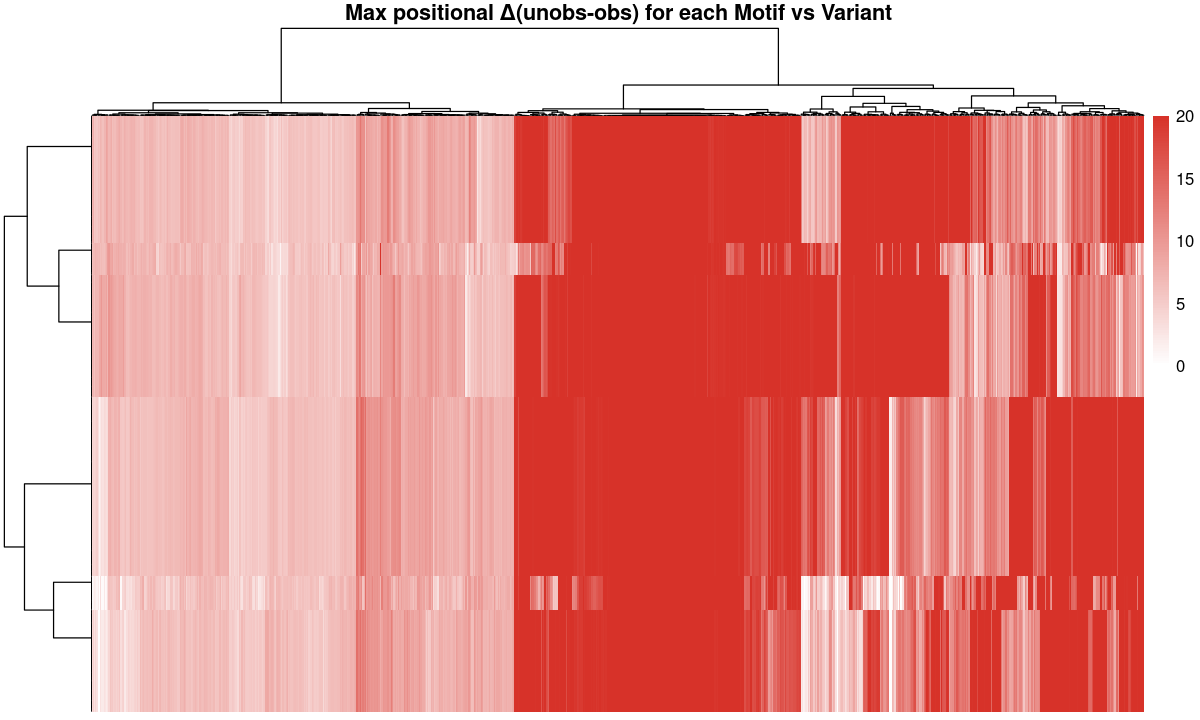

In [38]:
mat = mat_region_variant_score

options(repr.plot.height=6, repr.plot.width=10)
plt = pheatmap(
  mat_region_variant_score,
  color = colorRampPalette(c("white", "#d73027"))(100),
  breaks = seq(0, 20, length.out = 100),
  show_rownames = FALSE,
  show_colnames = FALSE,
  cluster_rows = TRUE,
  cluster_cols = TRUE,
  clustering_distance_rows = "euclidean",
  clustering_method = "ward.D2",
  main = "Max positional Δ(unobs-obs) for each Motif vs Variant"
)
